# Calibrate A Day

This notebook performs calibration of a day's averaged spectrum. This is the same as `edges2k.c`.

In [82]:
datadir: str = "/data4/smurray/edges/projects_with_nive/edges-bowman2018-pipeline/output-notebooks/" # "./cache"
year: int = 2016
day: int = 274
calfile: str = "/data4/smurray/edges/alans-pipeline/edges-cal-outputs/specal.txt"
alan_output_dir = "/data4/smurray/edges/alans-pipeline/scripts/H2CaseFieldData/"
outputsdir = "/data4/smurray/edges/projects_with_nive/edges-bowman2018-pipeline/outputs/"

fmin: float = 50   # Minimum freq to keep in the data       
fmax: float = 100  # Maximum freq to keep in the data

cal_freq_min: float = 51  # Minimum freq to *use* (i.e. with weight>0)
cal_freq_max: float = 99

do_beam_correction: bool = True
inject_beam: bool = True

## Imports and Data Load

In [83]:
from pathlib import Path
from importlib.metadata import version
from copy import deepcopy
import sys 

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un

from pygsdata import plots, GSData, GSFlag
from pygsdata.select import select_freqs

from edges_cal import Calibrator
from edges_cal.alanmode import read_specal_as_calibrator, read_spec_txt
from edges_cal import modelling as mdl

from edges_analysis.calibration.calibrate import apply_beam_correction, apply_loss_correction, apply_noise_wave_calibration
from edges_analysis.calibration.loss import low2_balun_connector_loss
from edges_analysis.averaging.freqbin import gauss_smooth
from edges_analysis.datamodel import add_model
from edges_analysis.filters import filters

In [84]:
print("Versions: ")
for pkg in ['read_acq', 'pygsdata', 'edges-cal', 'edges-io', 'edges-analysis']:
    print(f"{pkg:>20}: {version(pkg)}")


Versions: 
            read_acq: 1.0.3.dev17+gd442d34
            pygsdata: 0.2.1.dev41+g6af6948
           edges-cal: 6.2.6.dev199+g1cd9c07
            edges-io: 4.1.8.dev4+gdcc2fad
      edges-analysis: 6.0.3.dev72+g54f5323


In [85]:
def yday_to_alanday(year, day):
    if year == 2015:
        return day
    elif year == 2016:
        return 366 + day
    elif year == 2017:
        return 732 + day
    else:
        raise ValueError("Year must be 2015, 2016 or 2017")

In [86]:
datadir = Path(datadir)
alan_output_dir = Path(alan_output_dir) / str(yday_to_alanday(year, day))
outputsdir = Path(outputsdir)

In [87]:
obsname = f"{year}-{day:>03}"

In [88]:
pre_cal_data = GSData.from_file(datadir / f"{obsname}.averaged.gsh5")

In [89]:
if calfile.endswith(".txt"):
    calobs = read_specal_as_calibrator(calfile, t_load=300, t_load_ns=1000)
else:
    calobs = Calibrator.from_calfile(calfile)

## Plotting Functions

In [90]:
def plot_single_spectrum(data: GSData, alanspec = None, attribute='data'):
    if alanspec is not None:
        fig, ax = plt.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0, 'wspace':0}, constrained_layout=True, squeeze=False)
    else:    
        fig, ax = plt.subplots(1, 1, sharex=True, gridspec_kw={'hspace': 0, 'wspace':0}, constrained_layout=True, squeeze=False)
    
    flags = data.flagged_nsamples[0,0,0] == 0
    attr = getattr(data, attribute)[0,0,0]
    ax[0,0].plot(data.freqs, np.where(flags, np.nan, attr), label='edges-analysis')
    
    ax[0,0].set_ylabel("Temperature [K]")
    if alanspec is not None:
        ax[0,0].plot(data.freqs, np.where(flags, np.nan, alanspec), label='C-code')
        ax[1,0].plot(data.freqs, 1000*np.where(flags, np.nan, attr - alanspec), label='Difference', color='k')
        ax[1,0].set_ylabel("Difference [mK]")
        ax[1,0].legend(frameon=False)
        
    ax[-1,0].set_xlabel("Frequency [MHz]")
    
    ax[0,0].legend(frameon=False)

### Noise-Wave Calibration

In [91]:
nw_data = select_freqs(pre_cal_data, freq_range=(fmin, fmax))

frequency range given without units, assuming MHz.


In [92]:
nw_data = filters.flag_frequency_ranges(nw_data, freq_ranges=((cal_freq_min, cal_freq_max),), invert=True)

In [93]:
alan_pre_cal = np.genfromtxt(alan_output_dir/"spectra_before_noise_waves.txt")

In [94]:
nw_data = apply_noise_wave_calibration(
    nw_data,
    calobs = calobs,
    band='low',
    ant_s11_object=f"{outputsdir}/2015_ants11_modelled_redone.h5",
)

In [96]:
alan_output_dir

PosixPath('/data4/smurray/edges/alans-pipeline/scripts/H2CaseFieldData/640')

In [95]:
alan_spec_after_nw = np.genfromtxt(alan_output_dir/"spectra_after_noise_waves.txt", names=True)

ValueError: Some errors were detected !
    Line #873 (got 1 columns instead of 3)

In [34]:
alan_ants11 = np.genfromtxt(alan_output_dir/"modeled_antenna_s11.txt")

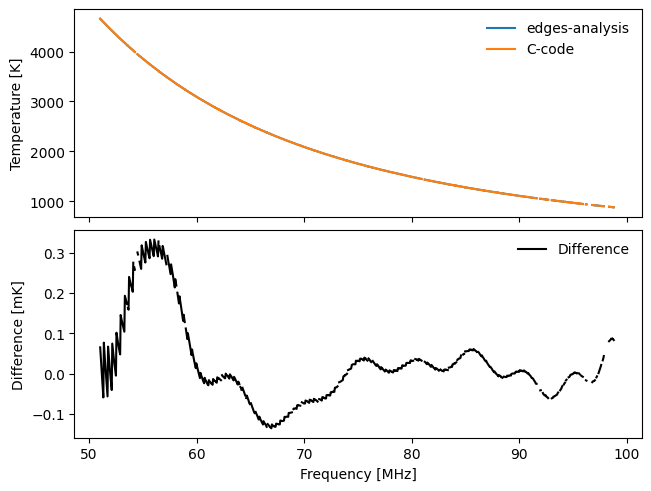

In [36]:
plot_single_spectrum(nw_data, alan_spec_after_nw['spec'])

### Loss-Correction

In [37]:
# Apply different loss corrections
loss_data = apply_loss_correction(
    nw_data, 
    ants11=f"{outputsdir}/2015_ants11_modelled_redone.h5", 
    ambient_temp=296*un.K, 
    loss_function=low2_balun_connector_loss, 
    use_approx_eps0=True
)
# no antenna correction
# no ground loss

In [38]:
alan_spec_after_loss = np.genfromtxt(alan_output_dir / "spectra_after_loss.txt", names=True)

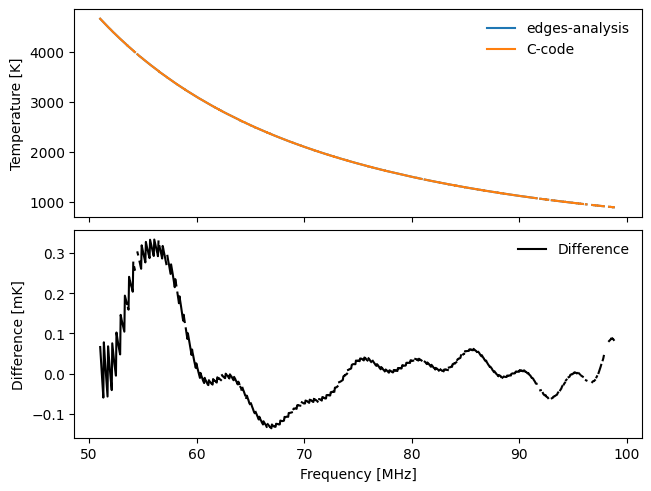

In [40]:
plot_single_spectrum(loss_data, alan_spec_after_loss['spec'])

### Beam Correction

In [62]:
if do_beam_correction:
    if inject_beam:
        beamfac = np.genfromtxt(alan_output_dir/'beamcorr.txt')
        beam_data = loss_data.update(data=loss_data.data * beamfac[:, 3])
    else:
        beam_data = apply_beam_correction(
            loss_data, 
            beam="/data4/nmahesh/edges/edges-field-levels/beam_factors/alan_newfc.h5",
            freq_model = mdl.Fourier(n_terms=31, transform=mdl.ShiftTransform(shift=75.0), period=72.0),
            resample_beam_lsts = False,
            integrate_before_ratio = True,
        )
else:
    beam_data = loss_data

In [63]:
# Get Alan's file after beam correction. NOTE: if beam correction is turned off in the script running the C-code, then this
# will NOT have beam correction actually applied, and will be the same as the previous plot.
alan_after_beam = np.genfromtxt(alan_output_dir/"spectra_after_beam.txt", names=True)

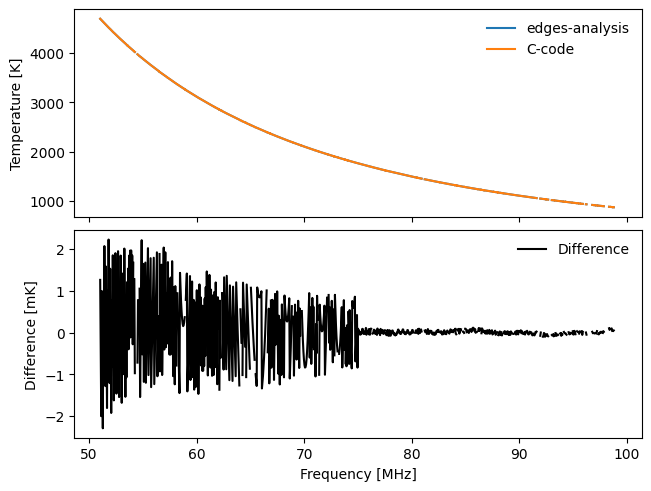

In [64]:
plot_single_spectrum(beam_data, alan_after_beam['spec'])

### Smooth Over Frequencies Again

In [67]:
data = add_model(beam_data, model=mdl.PhysicalLin(n_terms=3, spectral_index=-2.5, f_center=75.0, with_cmb=False), nsamples_strategy='flagged-nsamples-uniform')

In [68]:
alan_mdl = np.genfromtxt(alan_output_dir /"second_smooth_input.txt", names=True)

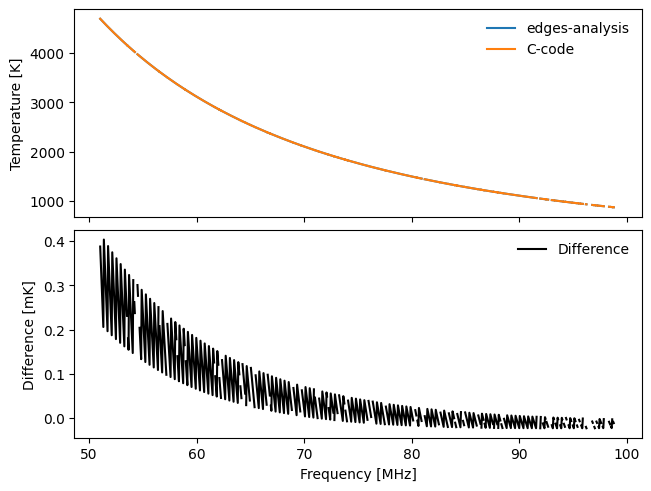

In [69]:
plot_single_spectrum(data, alan_mdl['model'], attribute='model')

In [70]:
data = gauss_smooth(data, size=8, nsmooth=2, decimate_at=0, maintain_flags=9, use_residuals=True, use_nsamples=False)

In [71]:
alan_specavg = np.genfromtxt(alan_output_dir / "specavg_cal.txt", usecols=(1,3,9))

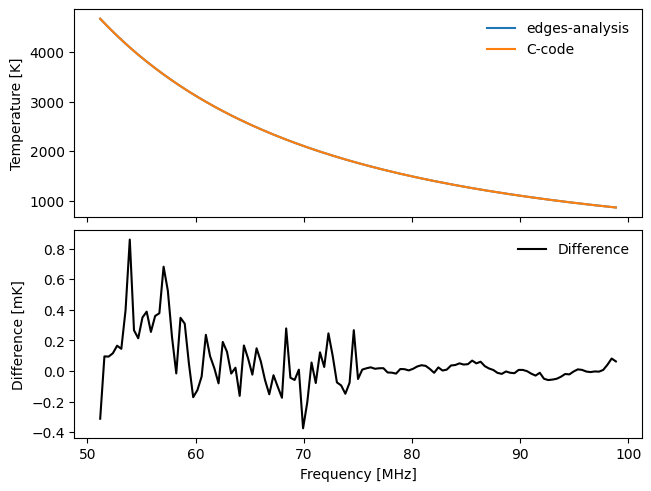

In [72]:
plot_single_spectrum(data, alan_specavg[:, 1])

In [74]:
data.write_gsh5(datadir / f"{obsname}.finalspec.gsh5");